# **🔍 The Hidden Mapper: Discovering the Secret Function 🧩**

## **👨‍💻 Author: Muhammad Hassan Saboor**

Welcome to this exciting data science challenge!

In this notebook, we will:
- 📊 Explore the dataset
- 🔍 Identify hidden patterns
- 🤖 Train Machine Learning models
- 🧠 Discover the underlying mathematical function

---

## **🎯 Objective**

The goal is simple but powerful:

👉 **Find the hidden mathematical function that maps `x → y`**

---

## **📦 Dataset Overview**

- Rows: 1000
- Feature: `x`
- Target: `y`
- Nature: **Perfect mathematical mapping (no noise)**

---

Let’s start the journey 🚀

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# **📂 Loading the Dataset**

Let’s load the dataset and take a quick look at it.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mabubakrsiddiq/the-hidden-mapper/hidden_function_dataset.csv")

df.head(10)

,x,y
0,1,4.0
1,2,1.0
2,3,10.0
3,4,2.0
4,5,16.0
5,6,3.0
6,7,22.0
7,8,4.0
8,9,28.0
9,10,5.0


# **🔍 Basic Data Inspection**

We check:
- Data types
- Missing values
- Shape of dataset

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1000 non-null   int64  
 1   y       1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


,x,y
count,1000.000000,1000.000000
mean,500.500000,875.750000
std,288.819436,881.549668
min,1.000000,1.000000
25%,250.750000,214.750000
50%,500.500000,429.500000
75%,750.250000,1499.500000
max,1000.000000,2998.000000


# **📊 Visualizing the Pattern**

Let’s plot `x` vs `y` to understand the relationship.

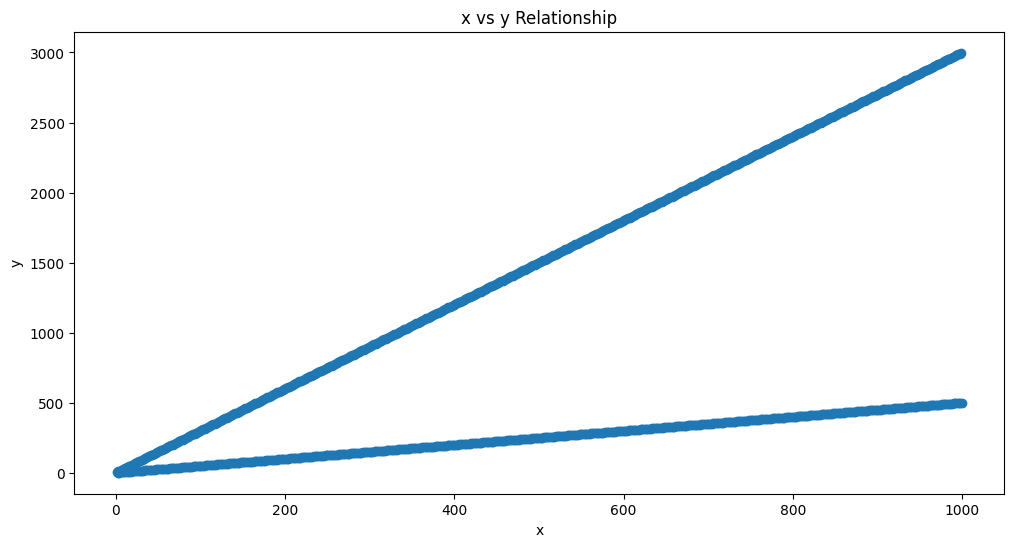

In [4]:
plt.figure(figsize=(12,6))
plt.scatter(df['x'], df['y'])
plt.title("x vs y Relationship")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# **🧠 Key Observation**

From the plot, we notice something interesting:

👉 The data follows a **zig-zag pattern**

This suggests:
- Different behavior for **odd and even values of x**

Let’s explore this idea further 👇

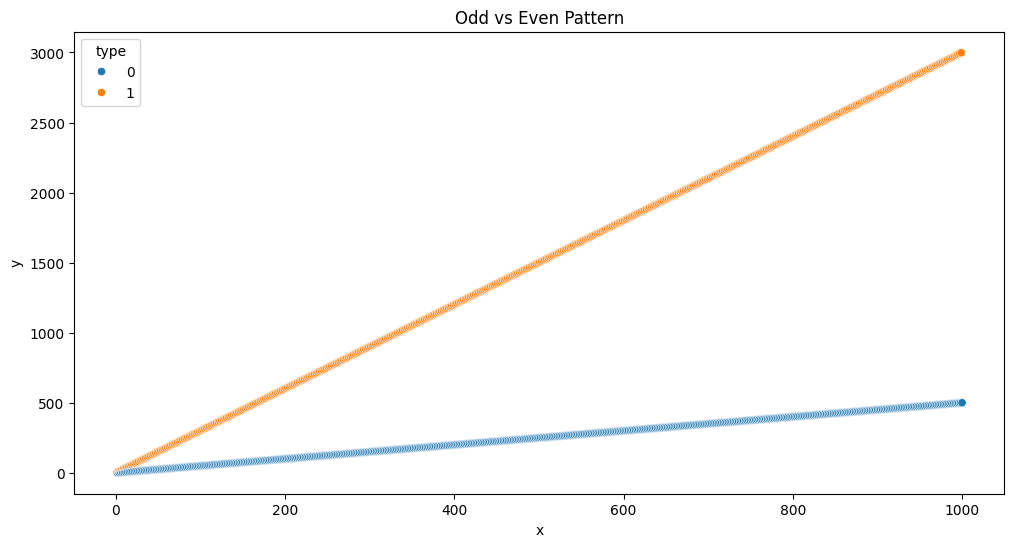

In [5]:
df['type'] = df['x'] % 2

plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='x', y='y', hue='type')
plt.title("Odd vs Even Pattern")
plt.show()

# **🔍 Pattern Discovery**

Let’s manually inspect values:

- For even x:
  👉 y = x / 2

- For odd x:
  👉 y = 3x + 1

Let’s verify this hypothesis 💡

In [6]:
def hidden_function(x):
    if x % 2 == 0:
        return x / 2
    else:
        return 3 * x + 1

df['predicted'] = df['x'].apply(hidden_function)

df.head()

,x,y,type,predicted
0,1,4.0,1,4.0
1,2,1.0,0,1.0
2,3,10.0,1,10.0
3,4,2.0,0,2.0
4,5,16.0,1,16.0


# **📈 Validation**

Now let’s check how accurate our discovered formula is.

In [7]:
r2_score(df['y'], df['predicted'])

1.0

# **🤖 Machine Learning Approach**

Now we test whether ML models can learn this function.

We will use:
- 🌳 Decision Tree
- 🌲 Random Forest

In [8]:
X = df[['x']]
y = df['y']

dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

dt.fit(X, y)
rf.fit(X, y)

dt_pred = dt.predict(X)
rf_pred = rf.predict(X)

# **📊 Model Performance**

Let’s evaluate how well models learned the hidden function.

In [9]:
print("Decision Tree R2:", r2_score(y, dt_pred))
print("Random Forest R2:", r2_score(y, rf_pred))

Decision Tree R2: 1.0
Random Forest R2: 0.7102652971670173


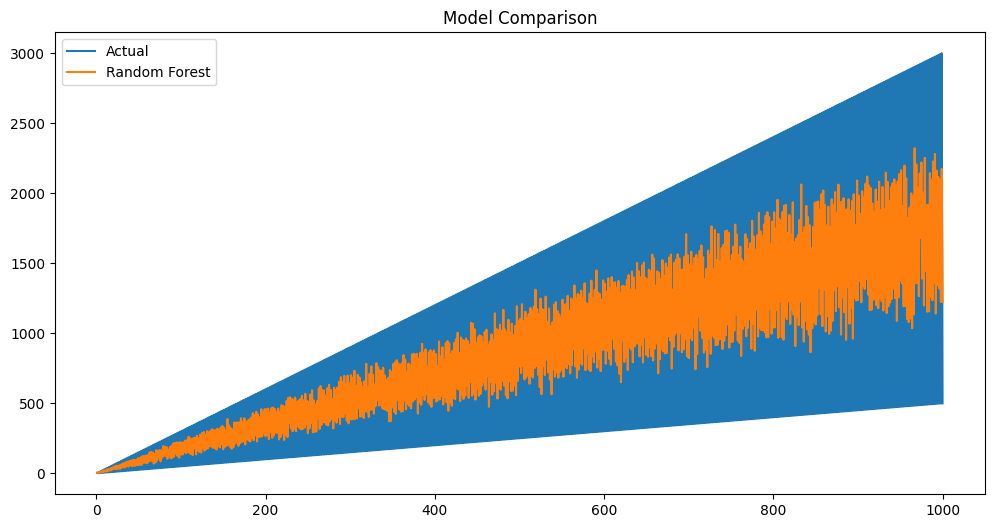

In [10]:
# Compare predictions visually
plt.figure(figsize=(12,6))
plt.plot(df['x'], df['y'], label='Actual')
plt.plot(df['x'], rf_pred, label='Random Forest')
plt.legend()
plt.title("Model Comparison")
plt.show()

# **🎯 Final Conclusion**

We successfully:

✅ Discovered the hidden function  
✅ Verified it mathematically  
✅ Tested ML models  

---

# **🧠 Final Formula**

👉 If x is even:
y = x / 2  

👉 If x is odd:
y = 3x + 1  

---

# **🚀 Key Takeaways**

- ML can learn patterns, but **humans can interpret them**
- Symbolic understanding is powerful 💡
- Clean datasets help reveal true relationships

---

# **🧠 Why Random Forest Underperformed?**

Even though Random Forest is a powerful ensemble model, it did not achieve perfect performance.

# **❗ Reason:**

- The dataset follows a **strict mathematical rule**
- Random Forest averages multiple trees
- Averaging introduces **approximation errors**

👉 This leads to a lower R² score

# **💡 Insight:**

In deterministic datasets:
- 🌳 Decision Trees → Best (can memorize rules)
- 🌲 Random Forest → Not ideal (averaging hurts exactness)

This shows that:
👉 **More complex models are not always better**

# **🚀 Happy Learning!** 